# SkinFusionNet — Model Development Notebook

---
### Prerequisites
| Notebook | Output Used Here |
|---|---|
| `DermAugment_Skin_Lesion_GAN_Pipeline.ipynb` | `DermAugFramework/ISIC2018_Balanced_1000/` — 1 000 images / class |
| `Derm_Stage_Label_Generation.ipynb` | `DermAugFramework/Final_SkinFusionNet_Labels/` — train / val / test CSVs + label_map.json |

### Pipeline
```
Stage-Labelled CSVs  (1 000 imgs × 8 classes, already augmented)
       │
       ▼  Resize 224×224 + ImageNet normalise  (NO extra augmentation)
       │
       ▼
SkinFusionNet (EfficientNet-B3 backbone)
  ├── DualPathModule
  │     ├── Local branch  : 1×1 conv + SE attention
  │     └── Global branch : dilated conv (r=2 & r=4) + SE attention
  ├── Shared neck  (LayerNorm + GELU + Dropout)
  ├── Disease head → 8-class softmax
  └── Stage head   → 3-class softmax  (NORMAL masked)
       │
       ▼
Evaluation → Grad-CAM → New-image inference → ONNX / TFLite export
```

## Section 1: Install & Import Dependencies

In [1]:
!pip install -q timm==0.9.16
!pip install -q onnx onnxruntime onnxscript
!pip install -q scikit-learn matplotlib seaborn tqdm pandas Pillow opencv-python-headless scipy
!pip install -q torchmetrics
print('Packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.7 MB/s eta 0:00:00
Packages installed.


In [2]:
import os, json, random, warnings, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
from scipy.stats import entropy as sp_entropy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix, balanced_accuracy_score
)
import onnx
import onnxruntime as ort

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

Device : cuda
GPU    : Tesla T4


## Section 2: Mount Google Drive & Configuration

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#  CONFIGURATION

LABELS_DIR     = '/content/drive/MyDrive/DermAugFramework/Final_SkinFusionNet_Labels'
TRAIN_CSV      = os.path.join(LABELS_DIR, 'train.csv')
VAL_CSV        = os.path.join(LABELS_DIR, 'val.csv')
TEST_CSV       = os.path.join(LABELS_DIR, 'test.csv')
LABEL_MAP_JSON = os.path.join(LABELS_DIR, 'label_map.json')

CKPT_DIR   = '/content/drive/MyDrive/DermAugFramework/SkinFusionNet_Checkpoints_v3'
EXPORT_DIR = '/content/drive/MyDrive/DermAugFramework/SkinFusionNet_Export_v3'
LOG_DIR    = '/content/drive/MyDrive/DermAugFramework/SkinFusionNet_Logs_V3'
for d in [CKPT_DIR, EXPORT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Hyper-parameters (tuned for 1000 imgs/class × 8 classes) ────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 24
NUM_WORKERS     = 2
NUM_EPOCHS      = 60

# EfficientNet-B4 replaces B3: more capacity, better feature separation
# for visually similar classes (NV/MEL, BCC/DF)
BACKBONE_NAME   = 'efficientnet_b4'

LR_BACKBONE     = 3e-5        # slower backbone unfreeze
LR_HEAD         = 2e-4
LR_MIN          = 1e-7
WEIGHT_DECAY    = 2e-4
LABEL_SMOOTHING = 0.10
DROPOUT_RATE    = 0.45
GRAD_CLIP       = 1.0
WARMUP_EPOCHS   = 5
PATIENCE        = 15          # generous patience to escape local minima
LAMBDA_DISEASE  = 1.0
LAMBDA_STAGE    = 0.25

# Mixup / CutMix
MIXUP_ALPHA     = 0.4         # stronger mixup helps inter-class boundaries
CUTMIX_ALPHA    = 1.0         # CutMix complements Mixup
MIXUP_PROB      = 0.5         # probability of applying mixup vs cutmix per batch

# Backbone unfreeze schedule
UNFREEZE_EPOCH  = 8           # freeze backbone for first N epochs, then unfreeze

DISEASE_CLASSES = ['NV', 'MEL', 'BKL', 'BCC', 'AKIEC', 'VASC', 'DF']
ALL_CLASSES     = DISEASE_CLASSES + ['NORMAL']
STAGES          = ['mild', 'moderate', 'severe']
NUM_DISEASE_CLS = len(ALL_CLASSES)
NUM_STAGE_CLS   = 3
NORMAL_CLASS_ID = ALL_CLASSES.index('NORMAL')

print('Checking input files ...')
all_ok = True
for p in [TRAIN_CSV, VAL_CSV, TEST_CSV, LABEL_MAP_JSON]:
    ok = os.path.exists(p)
    if not ok: all_ok = False
    print(f'  {"OK" if ok else "MISSING"}  {p}')
if not all_ok:
    raise FileNotFoundError('Run Stage Label Generation notebook first!')

print(f'\nBackbone     : {BACKBONE_NAME}')
print(f'Epochs       : {NUM_EPOCHS}  (patience={PATIENCE})')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Mixup α      : {MIXUP_ALPHA}  CutMix α : {CUTMIX_ALPHA}  P(mixup)={MIXUP_PROB}')
print(f'Unfreeze after epoch : {UNFREEZE_EPOCH}')
print(f'Classes ({NUM_DISEASE_CLS}) : {ALL_CLASSES}')

Checking input files ...
  OK  /content/drive/MyDrive/DermAugFramework/Final_SkinFusionNet_Labels/train.csv
  OK  /content/drive/MyDrive/DermAugFramework/Final_SkinFusionNet_Labels/val.csv
  OK  /content/drive/MyDrive/DermAugFramework/Final_SkinFusionNet_Labels/test.csv
  OK  /content/drive/MyDrive/DermAugFramework/Final_SkinFusionNet_Labels/label_map.json

Backbone     : efficientnet_b4
Epochs       : 60  (patience=15)
Batch size   : 24
Mixup α      : 0.4  CutMix α : 1.0  P(mixup)=0.5
Unfreeze after epoch : 8
Classes (8) : ['NV', 'MEL', 'BKL', 'BCC', 'AKIEC', 'VASC', 'DF', 'NORMAL']


## Section 3: Dataset Loader

In [5]:
# Load label map
with open(LABEL_MAP_JSON) as f:
    lmap = json.load(f)

LABEL_TO_ID = lmap['label_to_id']
ID_TO_LABEL = {int(k): v for k, v in lmap['id_to_label'].items()}
STAGE_TO_ID = lmap['stage_to_id']
ID_TO_STAGE = {int(k): v for k, v in lmap['id_to_stage'].items()}

print('Label map loaded:')
for cls, idx in LABEL_TO_ID.items():
    print(f'  {cls:8s} → {idx}')
print('Stage map:', STAGE_TO_ID)

Label map loaded:
  NV       → 0
  MEL      → 1
  BKL      → 2
  BCC      → 3
  AKIEC    → 4
  VASC     → 5
  DF       → 6
  NORMAL   → 7
Stage map: {'mild': 0, 'moderate': 1, 'severe': 2, 'none': -1}


In [6]:
# ImageNet statistics
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Single transform used for BOTH training and inference
# (no augmentation — DermAugment already done)
base_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

print('Transform: Resize + ToTensor + Normalize')

Transform: Resize + ToTensor + Normalize


Train : 5,600 images
Val   : 1,200 images
Test  : 1,200 images

Train class distribution (image chart):


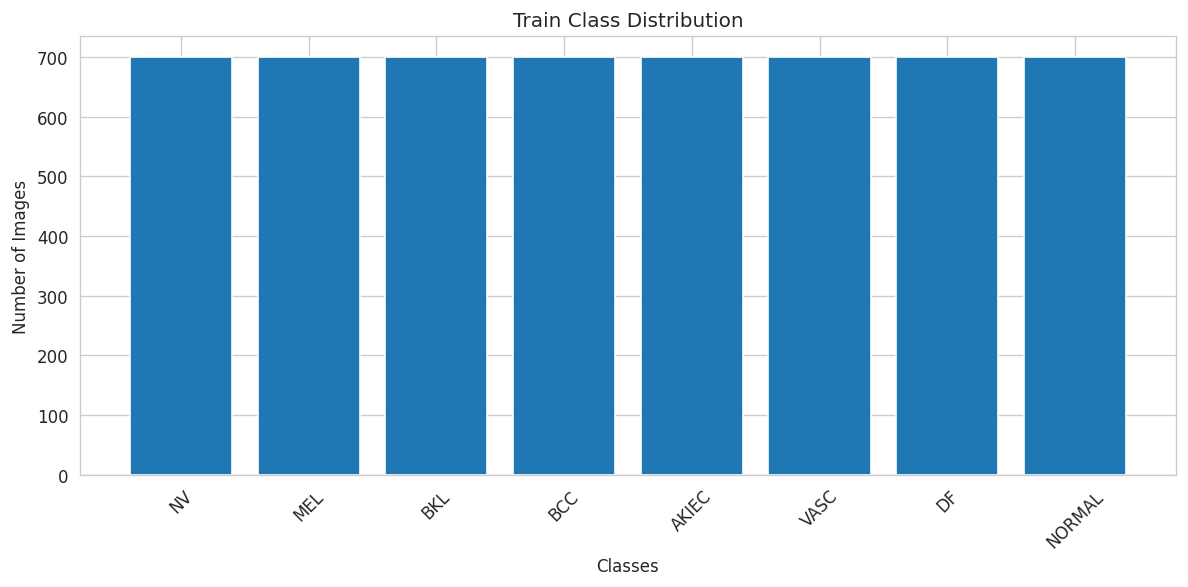

In [7]:
class SkinDataset(Dataset):
    """
    Reads CSVs produced by Stage Label Generation notebook.
    Columns: image_path, label, label_id, stage, stage_id
    NORMAL images have stage_id = -1 (masked in stage loss).
    """

    def __init__(self, csv_path, transform=None):
        self.df        = pd.read_csv(csv_path)
        self.transform = transform

        required = {'image_path', 'label', 'label_id', 'stage', 'stage_id'}
        missing  = required - set(self.df.columns)
        assert not missing, f'CSV missing columns: {missing}'

        exists = self.df['image_path'].apply(os.path.exists)
        dropped = (~exists).sum()
        if dropped:
            print(f'  WARNING: {dropped} rows dropped (image file not found)')
        self.df = self.df[exists].reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img      = Image.open(row['image_path']).convert('RGB')
        label_id = int(row['label_id'])
        stage_id = int(row['stage_id'])
        if self.transform:
            img = self.transform(img)
        return img, label_id, stage_id


train_ds = SkinDataset(TRAIN_CSV, transform=base_transform)
val_ds   = SkinDataset(VAL_CSV,   transform=base_transform)
test_ds  = SkinDataset(TEST_CSV,  transform=base_transform)

print(f'Train : {len(train_ds):,} images')
print(f'Val   : {len(val_ds):,} images')
print(f'Test  : {len(test_ds):,} images')

# Verify balance
print('\nTrain class distribution (image chart):')

vc = train_ds.df['label'].value_counts()

# Ensure all classes are included (even if missing)
counts = [vc.get(cls, 0) for cls in ALL_CLASSES]

plt.figure(figsize=(10, 5))
plt.bar(ALL_CLASSES, counts)

plt.title("Train Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# DataLoaders — shuffle=True on train; dataset already balanced so no sampler needed
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 233
Val   batches : 50
Test  batches : 50


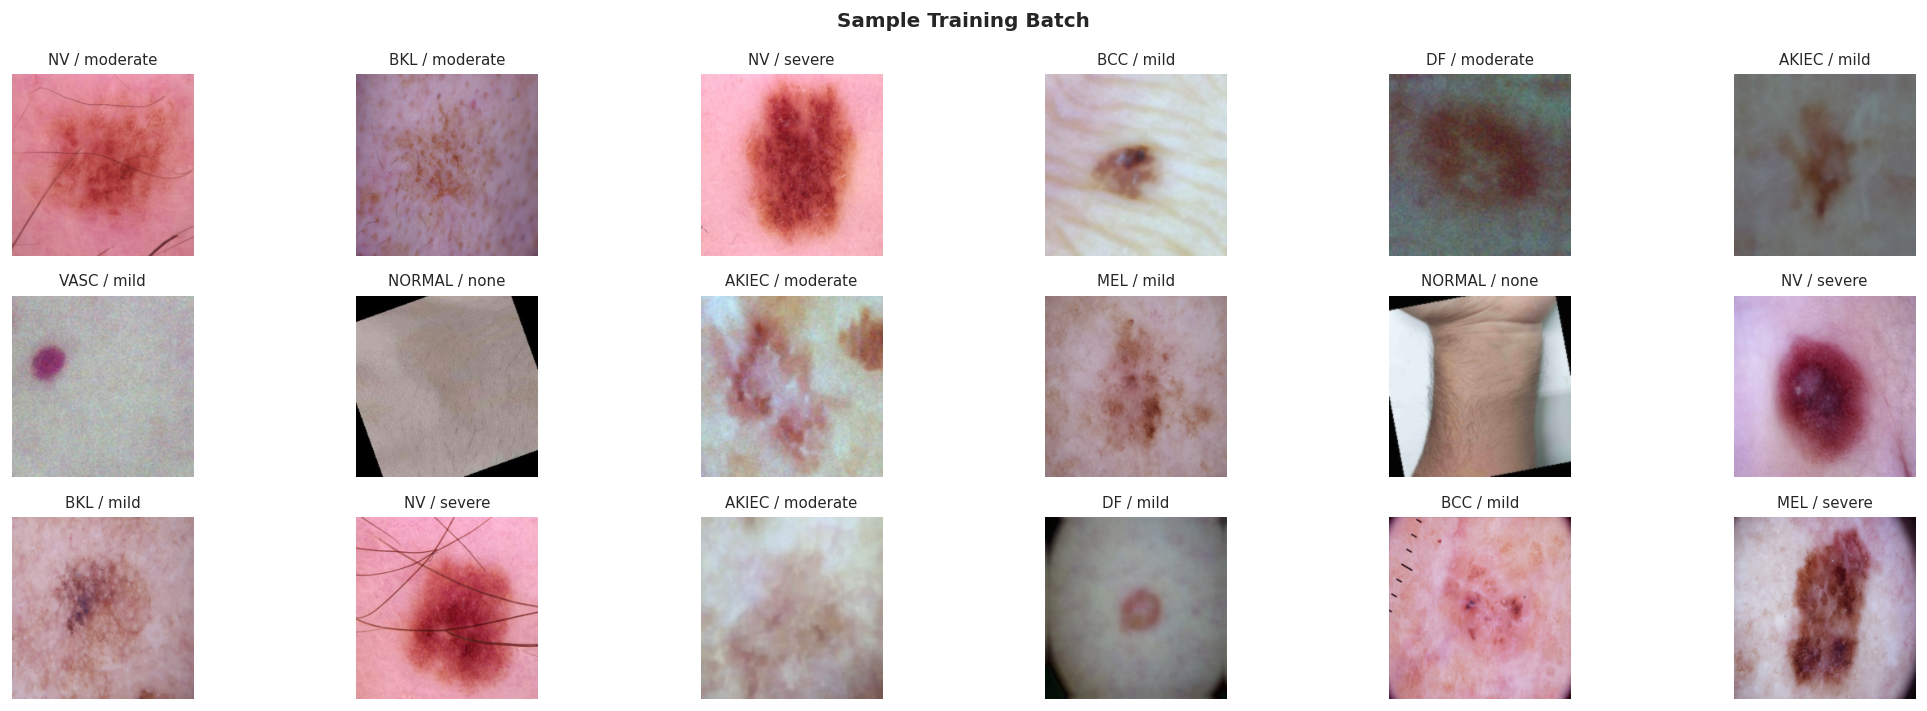

In [13]:
# Sample batch visualisation
def denorm(t):
    m = torch.tensor(MEAN).view(3,1,1)
    s = torch.tensor(STD).view(3,1,1)
    return torch.clamp(t * s + m, 0, 1)

imgs, labels, stages = next(iter(train_loader))
fig, axes = plt.subplots(3, 6, figsize=(18, 6))
fig.suptitle('Sample Training Batch',
             fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i >= 18: ax.axis('off'); continue
    ax.imshow(denorm(imgs[i]).permute(1,2,0).numpy())
    ax.set_title(f'{ID_TO_LABEL.get(labels[i].item(),"?")} / {ID_TO_STAGE.get(stages[i].item(),"none")}',
                 fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'viz_sample_batch.png'), bbox_inches='tight')
plt.show()

## Section 4: SkinFusionNet Architecture

```
Input (B, 3, 224, 224)
  │
  EfficientNet-B3 backbone — pretrained, features_only, last stage → (B, 1536, 7, 7)
  │
  DualPathModule
  ├─ Local branch   : Conv1×1 → BN → ReLU → SE
  └─ Global branch  : DilatedConv(r=2) ⊕ DilatedConv(r=4) → fuse → SE
  GAP both branches, concat → (B, 512)
  │
  Shared neck  : Linear(512,512) → LayerNorm → GELU → Dropout(0.4)
  │
  ├─ Disease head : Linear(512,256) → ReLU → Dropout(0.2) → Linear(256,8)
  └─ Stage head   : Linear(512,128) → ReLU → Dropout(0.2) → Linear(128,3)
```
**NORMAL attention design:** The stage loss is *masked* for NORMAL images during
training, so the model is never rewarded for concentrating attention on specific
skin spots when processing healthy images.  The Grad-CAM overlay for NORMAL
predictions uses a reduced alpha (0.20) to visually confirm the diffuse pattern.

In [14]:
# SkinFusionNet Architecture

# ── Squeeze-and-Excitation ────────────────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 8)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, mid), nn.ReLU(inplace=True),
            nn.Linear(mid, channels), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.se(x).unsqueeze(-1).unsqueeze(-1)


# ── Spatial Attention ─────────────────────────────────────────────────────────
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


# ── Full CBAM (channel + spatial) ─────────────────────────────────────────────
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel = SEBlock(channels, reduction)
        self.spatial = SpatialAttention(kernel_size)
    def forward(self, x):
        return self.spatial(self.channel(x))


# ── ASPP-style triple-dilated global branch ───────────────────────────────────
class ASPPModule(nn.Module):
    """
    Atrous Spatial Pyramid Pooling with three dilation rates + global avg.
    Captures multi-scale skin context: fine texture, lesion boundary, wide field.
    Critical for separating NV (small, uniform) from MEL (irregular borders).
    """
    def __init__(self, in_c, out_c):
        super().__init__()
        mid = out_c // 4
        self.d1 = nn.Sequential(
            nn.Conv2d(in_c, mid, 3, padding=2,  dilation=2,  bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.d2 = nn.Sequential(
            nn.Conv2d(in_c, mid, 3, padding=4,  dilation=4,  bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.d3 = nn.Sequential(
            nn.Conv2d(in_c, mid, 3, padding=6,  dilation=6,  bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_c, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.proj = nn.Sequential(
            nn.Conv2d(mid * 4, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True))

    def forward(self, x):
        h, w = x.shape[2:]
        g = F.interpolate(self.gap(x), size=(h, w), mode='bilinear', align_corners=False)
        return self.proj(torch.cat([self.d1(x), self.d2(x), self.d3(x), g], dim=1))


# ── Multi-Scale DualPathModule ────────────────────────────────────────────────
class DualPathModule(nn.Module):
    """
    Local  branch: 1×1 conv + CBAM  — fine lesion texture
    Global branch: ASPP             — multi-scale skin context
    Both are GAP-pooled and concatenated → (B, 2*out_dim)
    """
    def __init__(self, in_c, out_dim=256):
        super().__init__()
        self.local_branch = nn.Sequential(
            nn.Conv2d(in_c, out_dim, 1, bias=False),
            nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True),
            CBAM(out_dim),
        )
        self.global_branch = ASPPModule(in_c, out_dim)
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        loc = self.gap(self.local_branch(x)).flatten(1)
        glo = self.gap(self.global_branch(x)).flatten(1)
        return torch.cat([loc, glo], dim=1)   # (B, 2*out_dim)


# ── SkinFusionNet v3 ──────────────────────────────────────────────────────────
class SkinFusionNet(nn.Module):
    """
    Multi-scale feature fusion:
      - Stage 3 features (mid-level) : capture lesion shape & colour
      - Stage 4 features (deep)      : capture high-level semantic class info
    Both stages fed into separate DualPathModules, then concatenated.
    Temperature parameter τ on disease logits suppresses overconfidence.
    """
    def __init__(self, backbone_name='efficientnet_b4',
                 num_disease_cls=8, num_stage_cls=3,
                 path_dim=256, dropout=0.45, pretrained=True):
        super().__init__()

        # Extract BOTH stage-3 and stage-4 features
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained,
            features_only=True, out_indices=[3, 4]
        )
        with torch.no_grad():
            feats = self.backbone(torch.zeros(1, 3, 224, 224))
            in_c3 = feats[0].shape[1]   # stage-3 channels
            in_c4 = feats[1].shape[1]   # stage-4 channels
        print(f'  Backbone stage3 channels: {in_c3}  stage4 channels: {in_c4}')

        self.dual_path3 = DualPathModule(in_c3, path_dim)   # mid-level
        self.dual_path4 = DualPathModule(in_c4, path_dim)   # deep

        # Fuse both scales → 4*path_dim
        neck_in  = path_dim * 4
        neck_mid = 512
        self.neck = nn.Sequential(
            nn.Linear(neck_in, neck_mid),
            nn.LayerNorm(neck_mid), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(neck_mid, neck_mid),
            nn.LayerNorm(neck_mid), nn.GELU(), nn.Dropout(dropout * 0.5),
        )
        # Residual projection (neck_in → neck_mid) for skip connection
        self.neck_skip = nn.Linear(neck_in, neck_mid, bias=False)

        self.disease_head = nn.Sequential(
            nn.Linear(neck_mid, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_disease_cls),
        )
        self.stage_head = nn.Sequential(
            nn.Linear(neck_mid, 128), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_stage_cls),
        )

        # Learnable temperature for calibrated confidence
        # τ > 1 → softer probabilities, reduces overconfident wrong predictions
        self.log_temp = nn.Parameter(torch.zeros(1))   # τ = exp(log_temp)

        self._init_new()

    def _init_new(self):
        for m in [self.dual_path3, self.dual_path4,
                  self.neck, self.neck_skip,
                  self.disease_head, self.stage_head]:
            for layer in m.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, mode='fan_out')
                    if layer.bias is not None: nn.init.zeros_(layer.bias)
                elif isinstance(layer, nn.Conv2d):
                    nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
                elif isinstance(layer, (nn.BatchNorm2d, nn.LayerNorm)):
                    nn.init.ones_(layer.weight); nn.init.zeros_(layer.bias)

    def forward(self, x):
        f3, f4   = self.backbone(x)            # multi-scale features
        feat3    = self.dual_path3(f3)          # (B, 2*path_dim)
        feat4    = self.dual_path4(f4)          # (B, 2*path_dim)
        fused    = torch.cat([feat3, feat4], 1) # (B, 4*path_dim)
        neck_out = self.neck(fused) + self.neck_skip(fused)  # residual
        # Temperature-scaled disease logits
        temp     = self.log_temp.exp().clamp(min=0.5, max=5.0)
        d_logits = self.disease_head(neck_out) / temp
        s_logits = self.stage_head(neck_out)
        return d_logits, s_logits


# Instantiate
model = SkinFusionNet(
    backbone_name=BACKBONE_NAME,
    num_disease_cls=NUM_DISEASE_CLS,
    num_stage_cls=NUM_STAGE_CLS,
    path_dim=256, dropout=DROPOUT_RATE,
).to(DEVICE)

with torch.no_grad():
    _d, _s = model(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f'Disease logits : {_d.shape}  (expect [2, {NUM_DISEASE_CLS}])')
print(f'Stage   logits : {_s.shape}  (expect [2, {NUM_STAGE_CLS}])')
print(f'Total params   : {sum(p.numel() for p in model.parameters()):,}')
print('Architecture: EfficientNet-B4 + Multi-Scale DualPath (CBAM+ASPP) + ResNeck + TempScale')

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

  Backbone stage3 channels: 160  stage4 channels: 448
Disease logits : torch.Size([2, 8])  (expect [2, 8])
Stage   logits : torch.Size([2, 3])  (expect [2, 3])
Total params   : 19,651,896
Architecture: EfficientNet-B4 + Multi-Scale DualPath (CBAM+ASPP) + ResNeck + TempScale


## Section 5: Loss Functions & Class Weights

In [15]:
# ── Per-class weights ─────────────────────────────────────────────────────────
train_counts = np.bincount(
    train_ds.df['label_id'].values, minlength=NUM_DISEASE_CLS
).astype(float)

disease_weights = torch.tensor(
    1.0 / (train_counts + 1e-6), dtype=torch.float32
).to(DEVICE)
disease_weights = disease_weights / disease_weights.sum() * NUM_DISEASE_CLS

print('Per-class loss weights (should be ~1.0 for balanced data):')
for cls, cnt, w in zip(ALL_CLASSES, train_counts, disease_weights.cpu()):
    print(f'  {cls:8s}  {cnt:5.0f} imgs   weight = {w:.4f}')


# ── Focal Loss ────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.10):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.weight          = weight

    def forward(self, logits, targets):
        n_cls    = logits.size(1)
        smooth   = self.label_smoothing / n_cls
        log_prob = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            soft_t = torch.full_like(log_prob, smooth)
            soft_t.scatter_(1, targets.unsqueeze(1).long(),
                            1.0 - self.label_smoothing + smooth)
        loss = -(soft_t * log_prob).sum(dim=1)
        pt   = torch.exp(-F.cross_entropy(logits, targets.long(), reduction='none'))
        loss = (1 - pt) ** self.gamma * loss
        if self.weight is not None:
            loss = loss * self.weight[targets.long()]
        return loss.mean()


# ── Confusion-Aware Penalty ───────────────────────────────────────────────────
# Explicitly penalises the three most confused class pairs seen in the
# test grid: NV↔MEL, BCC↔DF.  For each confused pair, we add extra
# loss when the model assigns high probability to the wrong class.
class ConfusionPenaltyLoss(nn.Module):
    """
    For each confused pair (a, b): when true=a and the model assigns
    p(b) > threshold, add a margin penalty.
    This directly targets the observed error patterns.
    """
    def __init__(self, confused_pairs, label_to_id, margin=0.3, weight=0.5):
        super().__init__()
        self.pairs  = [(label_to_id[a], label_to_id[b]) for a, b in confused_pairs]
        self.margin = margin
        self.weight = weight

    def forward(self, logits, targets):
        probs  = F.softmax(logits, dim=1)   # (B, C)
        penalty = torch.zeros(logits.size(0), device=logits.device)
        for (a, b) in self.pairs:
            # True=a, but model gives high prob to b  → penalise
            mask_a = (targets == a)
            if mask_a.any():
                penalty[mask_a] += F.relu(probs[mask_a, b] - self.margin)
            # True=b, but model gives high prob to a  → penalise
            mask_b = (targets == b)
            if mask_b.any():
                penalty[mask_b] += F.relu(probs[mask_b, a] - self.margin)
        return self.weight * penalty.mean()


# Observed confused pairs from test grid image
CONFUSED_PAIRS = [('NV', 'MEL'), ('BCC', 'DF'), ('MEL', 'BKL')]

disease_criterion = FocalLoss(
    weight=disease_weights, gamma=2.0, label_smoothing=LABEL_SMOOTHING
)
confusion_penalty = ConfusionPenaltyLoss(
    CONFUSED_PAIRS, LABEL_TO_ID, margin=0.3, weight=0.4
)
stage_criterion   = nn.CrossEntropyLoss(reduction='none')


def masked_stage_loss(s_logits, s_ids):
    mask = (s_ids >= 0)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=s_logits.device, requires_grad=True)
    return stage_criterion(s_logits[mask], s_ids[mask].long()).mean()


def combined_loss(d_log, d_ids, s_log, s_ids):
    dl  = disease_criterion(d_log, d_ids.long())
    cp  = confusion_penalty(d_log, d_ids.long())
    sl  = masked_stage_loss(s_log, s_ids)
    tot = LAMBDA_DISEASE * dl + cp + LAMBDA_STAGE * sl
    return tot, dl.item(), sl.item()


print(f'\nFocal loss (γ=2.0) + ConfusionPenalty on {CONFUSED_PAIRS}')
print('Loss functions ready.')

Per-class loss weights (should be ~1.0 for balanced data):
  NV          700 imgs   weight = 1.0000
  MEL         700 imgs   weight = 1.0000
  BKL         700 imgs   weight = 1.0000
  BCC         700 imgs   weight = 1.0000
  AKIEC       700 imgs   weight = 1.0000
  VASC        700 imgs   weight = 1.0000
  DF          700 imgs   weight = 1.0000
  NORMAL      700 imgs   weight = 1.0000

Focal loss (γ=2.0) + ConfusionPenalty on [('NV', 'MEL'), ('BCC', 'DF'), ('MEL', 'BKL')]
Loss functions ready.


## Section 6: Training Loop

In [16]:
# ── Optimiser with differential learning rates ────────────────────────────────
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(),      'lr': LR_BACKBONE},
    {'params': model.dual_path3.parameters(),    'lr': LR_HEAD},
    {'params': model.dual_path4.parameters(),    'lr': LR_HEAD},
    {'params': model.neck.parameters(),          'lr': LR_HEAD},
    {'params': model.neck_skip.parameters(),     'lr': LR_HEAD},
    {'params': model.disease_head.parameters(),  'lr': LR_HEAD},
    {'params': model.stage_head.parameters(),    'lr': LR_HEAD},
    {'params': [model.log_temp],                 'lr': LR_HEAD * 0.1},
], weight_decay=WEIGHT_DECAY)

total_steps  = NUM_EPOCHS * len(train_loader)
warmup_steps = WARMUP_EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(warmup_steps, 1)
    p = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return max(LR_MIN / LR_HEAD, 0.5 * (1 + np.cos(np.pi * p)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


# ── Freeze backbone initially — only train heads for UNFREEZE_EPOCH epochs ────
def set_backbone_grad(requires_grad: bool):
    for p in model.backbone.parameters():
        p.requires_grad = requires_grad

set_backbone_grad(False)   # start frozen
print(f'Backbone frozen for first {UNFREEZE_EPOCH} epochs.')


# ── Mixup helper ──────────────────────────────────────────────────────────────
def mixup_data(x, y_d, y_s, alpha=0.4):
    if alpha <= 0:
        return x, y_d, y_s, y_d, y_s, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[idx], y_d, y_s, y_d[idx], y_s[idx], lam


# ── CutMix helper ─────────────────────────────────────────────────────────────
def rand_bbox(size, lam):
    """Returns random bounding box for CutMix."""
    W, H  = size[3], size[2]
    ratio = np.sqrt(1 - lam)
    cut_w = int(W * ratio)
    cut_h = int(H * ratio)
    cx    = np.random.randint(W)
    cy    = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2


def cutmix_data(x, y_d, y_s, alpha=1.0):
    if alpha <= 0:
        return x, y_d, y_s, y_d, y_s, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x_cut          = x.clone()
    x_cut[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam_actual     = 1 - (x2-x1)*(y2-y1) / (x.size(2)*x.size(3))
    return x_cut, y_d, y_s, y_d[idx], y_s[idx], lam_actual


def apply_mix(x, y_d, y_s):
    """Randomly choose Mixup or CutMix per batch."""
    if np.random.rand() < MIXUP_PROB:
        return mixup_data(x, y_d, y_s, MIXUP_ALPHA)
    else:
        return cutmix_data(x, y_d, y_s, CUTMIX_ALPHA)


def mixup_loss(d_log, d_a, d_b, s_log, s_a, s_b, lam):
    la = combined_loss(d_log, d_a, s_log, s_a)
    lb = combined_loss(d_log, d_b, s_log, s_b)
    return lam * la[0] + (1-lam) * lb[0], la[1], la[2]


print(f'Optimiser : AdamW  backbone LR={LR_BACKBONE}  heads LR={LR_HEAD}')
print(f'Scheduler : cosine + {WARMUP_EPOCHS}-epoch warm-up')
print(f'Mix       : Mixup(α={MIXUP_ALPHA}) + CutMix(α={CUTMIX_ALPHA})  P(mixup)={MIXUP_PROB}')

Backbone frozen for first 8 epochs.
Optimiser : AdamW  backbone LR=3e-05  heads LR=0.0002
Scheduler : cosine + 5-epoch warm-up
Mix       : Mixup(α=0.4) + CutMix(α=1.0)  P(mixup)=0.5


In [17]:
def train_epoch(model, loader, opt, sched, scaler, epoch):
    # Unfreeze backbone after UNFREEZE_EPOCH epochs
    if epoch == UNFREEZE_EPOCH + 1:
        set_backbone_grad(True)
        print(f'  [Epoch {epoch}] Backbone UNFROZEN — full fine-tuning begins.')

    model.train()
    run_loss = correct = total = 0
    for imgs, d_ids, s_ids in tqdm(loader, desc='  train', leave=False):
        imgs  = imgs.to(DEVICE,  non_blocking=True)
        d_ids = d_ids.to(DEVICE, non_blocking=True)
        s_ids = s_ids.to(DEVICE, non_blocking=True)

        imgs_m, d_a, s_a, d_b, s_b, lam = apply_mix(imgs, d_ids, s_ids)

        opt.zero_grad()
        with torch.cuda.amp.autocast():
            d_log, s_log = model(imgs_m)
            loss, _, _   = mixup_loss(d_log, d_a, d_b, s_log, s_a, s_b, lam)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt); scaler.update(); sched.step()

        bs        = imgs.size(0)
        run_loss += loss.item() * bs
        correct  += (d_log.argmax(1) == d_ids).sum().item()
        total    += bs
    n = len(loader.dataset)
    return dict(loss=run_loss/n, acc=correct/total)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    run_loss = 0
    all_pred, all_lbl = [], []
    for imgs, d_ids, s_ids in tqdm(loader, desc='  eval ', leave=False):
        imgs  = imgs.to(DEVICE,  non_blocking=True)
        d_ids = d_ids.to(DEVICE, non_blocking=True)
        s_ids = s_ids.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast():
            d_log, s_log = model(imgs)
            loss, _, _   = combined_loss(d_log, d_ids, s_log, s_ids)
        run_loss += loss.item() * imgs.size(0)
        all_pred.extend(d_log.argmax(1).cpu().numpy())
        all_lbl.extend(d_ids.cpu().numpy())
    p, l = np.array(all_pred), np.array(all_lbl)
    return dict(
        loss    = run_loss / len(loader.dataset),
        acc     = float(np.mean(p == l)),
        bal_acc = balanced_accuracy_score(l, p),
        preds=p, labels=l,
    )


print('Train / eval helpers ready  (Mixup + CutMix + backbone unfreeze schedule).')

Train / eval helpers ready  (Mixup + CutMix + backbone unfreeze schedule).


In [18]:
scaler       = torch.cuda.amp.GradScaler()
history      = defaultdict(list)
best_bal_acc = best_val_acc = 0.0
best_epoch   = patience_ctr = 0
best_ckpt    = os.path.join(CKPT_DIR, 'skinfusionnet_best.pth')
last_ckpt    = os.path.join(CKPT_DIR, 'skinfusionnet_last.pth')

print(f'Training for up to {NUM_EPOCHS} epochs (patience={PATIENCE}) ...\n')
t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t_ep = time.time()
    tr   = train_epoch(model, train_loader, optimizer, scheduler, scaler, epoch)
    vl   = evaluate(model, val_loader)

    for k, v in tr.items():  history[f'tr_{k}'].append(v)
    for k in ('loss','acc','bal_acc'):  history[f'vl_{k}'].append(vl[k])

    # Log temperature
    tau      = model.log_temp.exp().item()
    cur_lr   = optimizer.param_groups[1]['lr']
    improved = vl['bal_acc'] > best_bal_acc
    flag     = '  <- BEST' if improved else ''

    print(f'Ep {epoch:3d}/{NUM_EPOCHS}  '
          f'tr_loss={tr["loss"]:.4f} tr_acc={tr["acc"]:.4f}  '
          f'vl_loss={vl["loss"]:.4f} vl_acc={vl["acc"]:.4f} '
          f'vl_bal={vl["bal_acc"]:.4f}  τ={tau:.3f}  lr={cur_lr:.2e}  '
          f'({time.time()-t_ep:.0f}s){flag}')

    if improved:
        best_bal_acc = vl['bal_acc']
        best_val_acc = vl['acc']
        best_epoch   = epoch
        patience_ctr = 0
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'val_acc'     : best_val_acc,
            'val_bal_acc' : best_bal_acc,
            'config'      : {
                'backbone_name'   : BACKBONE_NAME,
                'num_disease_cls' : NUM_DISEASE_CLS,
                'num_stage_cls'   : NUM_STAGE_CLS,
                'img_size'        : IMG_SIZE,
                'label_to_id'     : LABEL_TO_ID,
                'stage_to_id'     : STAGE_TO_ID,
                'mean'            : MEAN,
                'std'             : STD,
            }
        }, best_ckpt)
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

    if epoch % 5 == 0:
        torch.save({'epoch': epoch, 'model_state': model.state_dict()}, last_ckpt)

print(f'\nTotal time  : {(time.time()-t0)/60:.1f} min')
print(f'Best epoch  : {best_epoch}')
print(f'Best val acc: {best_val_acc*100:.2f}%  |  Balanced: {best_bal_acc*100:.2f}%')

Training for up to 60 epochs (patience=15) ...



Ep   1/60  tr_loss=13.7081 tr_acc=0.1622  vl_loss=4.4144 vl_acc=0.3583 vl_bal=0.3584  τ=1.000  lr=4.00e-05  (1200s)  <- BEST


Ep   2/60  tr_loss=5.4501 tr_acc=0.2189  vl_loss=1.7874 vl_acc=0.2900 vl_bal=0.2902  τ=1.001  lr=8.00e-05  (75s)


Ep   3/60  tr_loss=1.8004 tr_acc=0.2423  vl_loss=1.3132 vl_acc=0.4208 vl_bal=0.4211  τ=1.002  lr=1.20e-04  (75s)  <- BEST


Ep   4/60  tr_loss=1.6064 tr_acc=0.2700  vl_loss=1.1894 vl_acc=0.4292 vl_bal=0.4290  τ=1.003  lr=1.60e-04  (77s)  <- BEST


...

Ep  52/60  tr_loss=0.8899 tr_acc=0.5649  vl_loss=0.5027 vl_acc=0.7900 vl_bal=0.7900  τ=1.052  lr=1.03e-05  (87s)


Ep  53/60  tr_loss=0.8572 tr_acc=0.5567  vl_loss=0.5020 vl_acc=0.7892 vl_bal=0.7891  τ=1.052  lr=7.89e-06  (88s)


Ep  54/60  tr_loss=0.8726 tr_acc=0.5508  vl_loss=0.5058 vl_acc=0.7900 vl_bal=0.7900  τ=1.052  lr=5.82e-06  (88s)


Ep  55/60  tr_loss=0.8973 tr_acc=0.5379  vl_loss=0.5135 vl_acc=0.7833 vl_bal=0.7833  τ=1.052  lr=4.05e-06  (87s)


Ep  56/60  tr_loss=0.8655 tr_acc=0.5669  vl_loss=0.5093 vl_acc=0.7867 vl_bal=0.7866  τ=1.052  lr=2.60e-06  (89s)

Early stopping at epoch 56.

Total time  : 100.4 min
Best epoch  : 41
Best val acc: 79.42%  |  Balanced: 79.41%


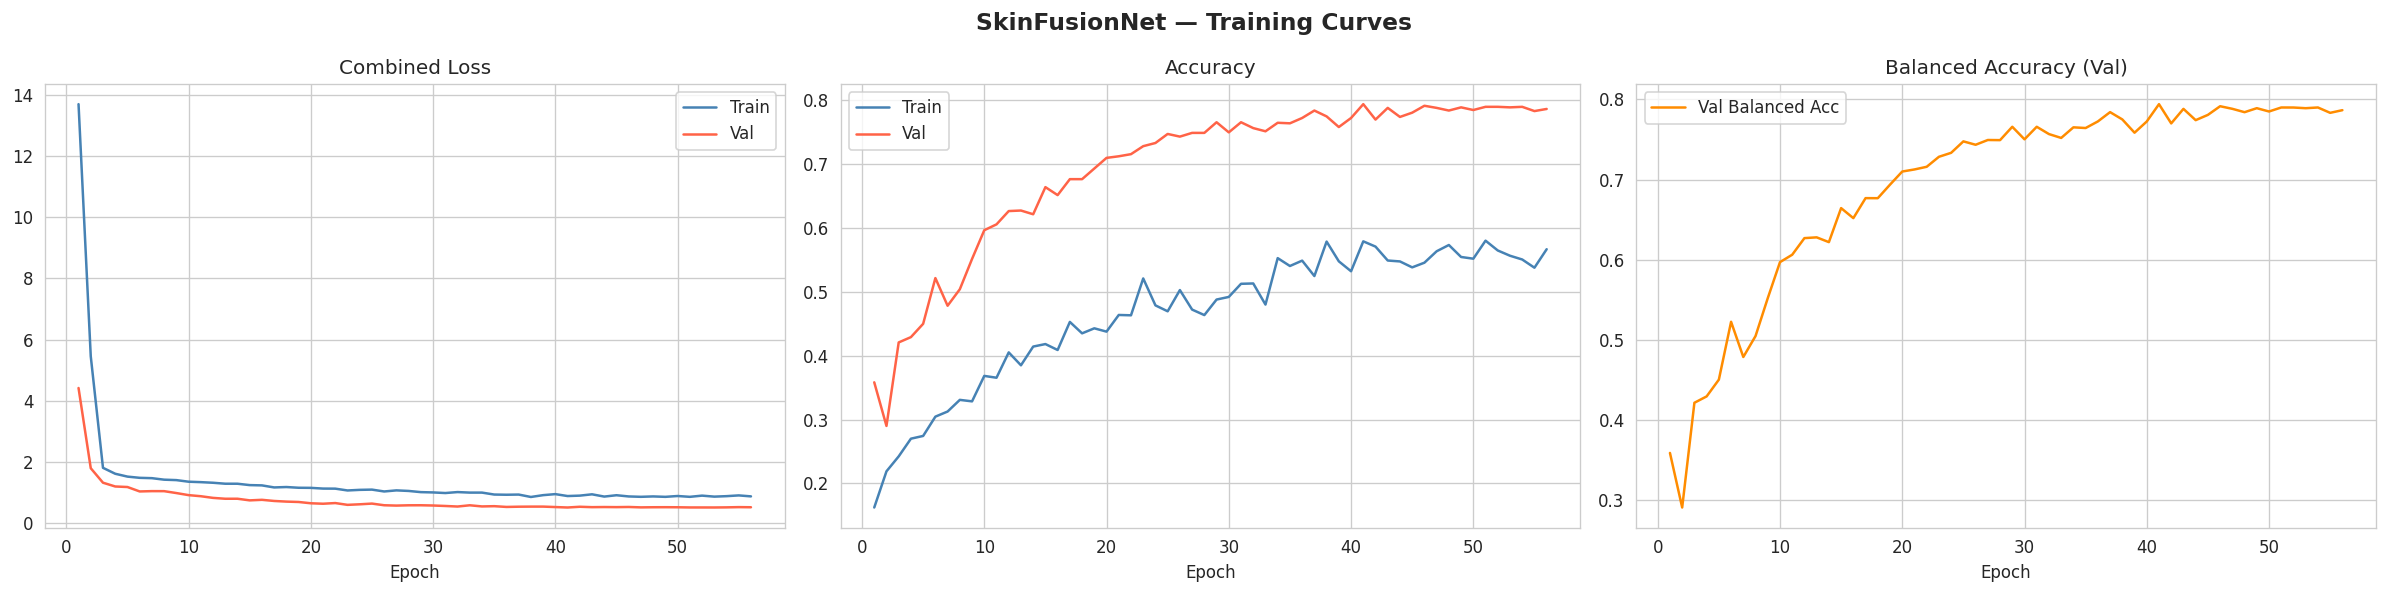

In [19]:
# Training curves
ep_x = range(1, len(history['tr_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('SkinFusionNet — Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(ep_x, history['tr_loss'], label='Train', color='steelblue')
axes[0].plot(ep_x, history['vl_loss'], label='Val',   color='tomato')
axes[0].set_title('Combined Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep_x, history['tr_acc'], label='Train', color='steelblue')
axes[1].plot(ep_x, history['vl_acc'], label='Val',   color='tomato')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(ep_x, history['vl_bal_acc'], color='darkorange', label='Val Balanced Acc')
axes[2].set_title('Balanced Accuracy (Val)'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'viz_training_curves.png'), bbox_inches='tight')
plt.show()

## Section 7: Evaluation & Confusion Matrix

In [20]:
ckpt = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'Best checkpoint loaded  epoch={ckpt["epoch"]}  '
      f'val_acc={ckpt["val_acc"]:.4f}  val_bal_acc={ckpt["val_bal_acc"]:.4f}')

Best checkpoint loaded  epoch=41  val_acc=0.7942  val_bal_acc=0.7941


In [22]:
test_m = evaluate(model, test_loader)

print('\n' + '='*62)
print('  TEST SET RESULTS')
print('='*62)
print(f'  Accuracy          : {test_m["acc"]*100:.2f}%')
print(f'  Balanced Accuracy : {test_m["bal_acc"]*100:.2f}%')
print('='*62)
print()
print(classification_report(
    test_m['labels'], test_m['preds'],
    target_names=ALL_CLASSES, digits=4
))


  TEST SET RESULTS
  Accuracy          : 81.00%
  Balanced Accuracy : 81.00%

              precision    recall  f1-score   support

          NV     0.7785    0.8200    0.7987       150
         MEL     0.7638    0.6467    0.7004       150
         BKL     0.6748    0.7285    0.7006       151
         BCC     0.7310    0.7114    0.7211       149
       AKIEC     0.7448    0.7200    0.7322       150
        VASC     0.9539    0.9667    0.9603       150
          DF     0.8313    0.8867    0.8581       150
      NORMAL     1.0000    1.0000    1.0000       150

    accuracy                         0.8100      1200
   macro avg     0.8098    0.8100    0.8089      1200
weighted avg     0.8097    0.8100    0.8089      1200



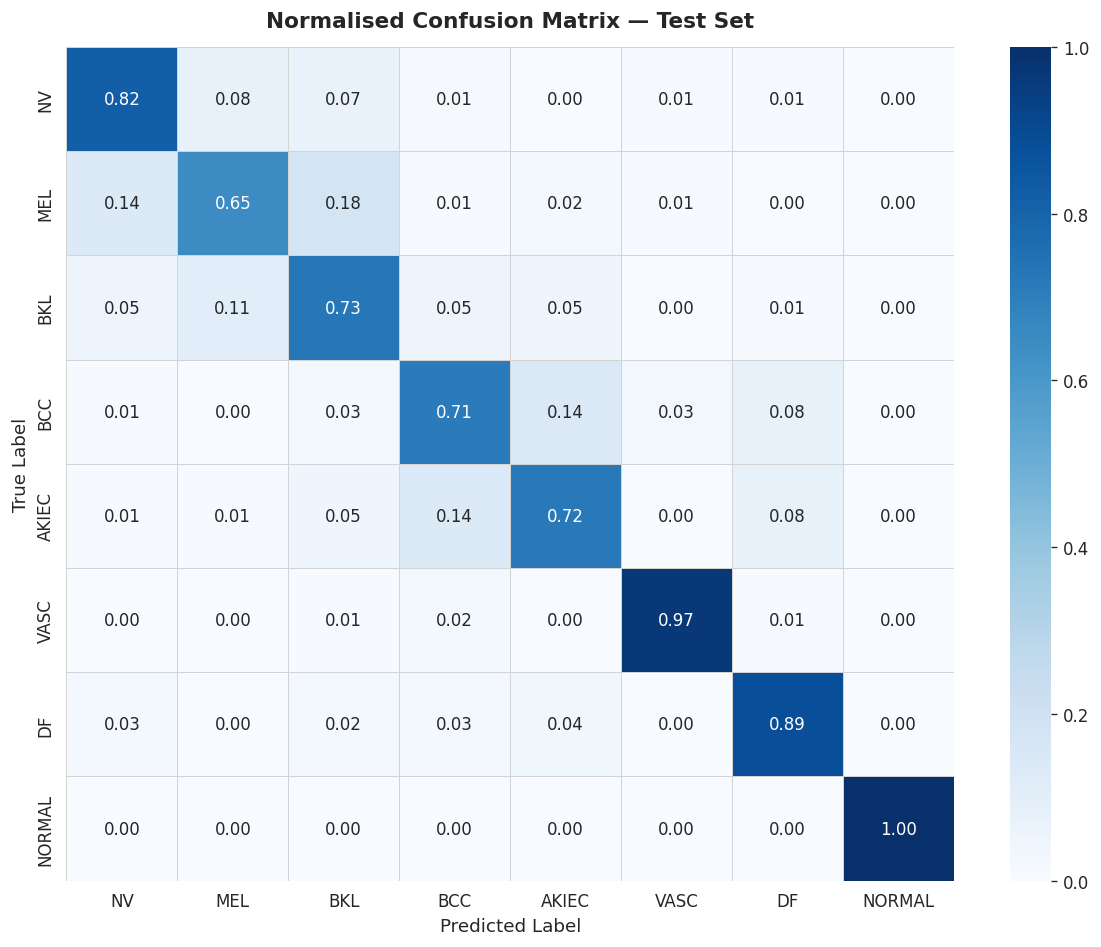

In [23]:
# Normalised confusion matrix
cm = confusion_matrix(test_m['labels'], test_m['preds'], normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=ALL_CLASSES, yticklabels=ALL_CLASSES,
            ax=ax, linewidths=0.5, linecolor='lightgray')
ax.set_title('Normalised Confusion Matrix — Test Set',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'viz_confusion_matrix.png'), bbox_inches='tight')
plt.show()

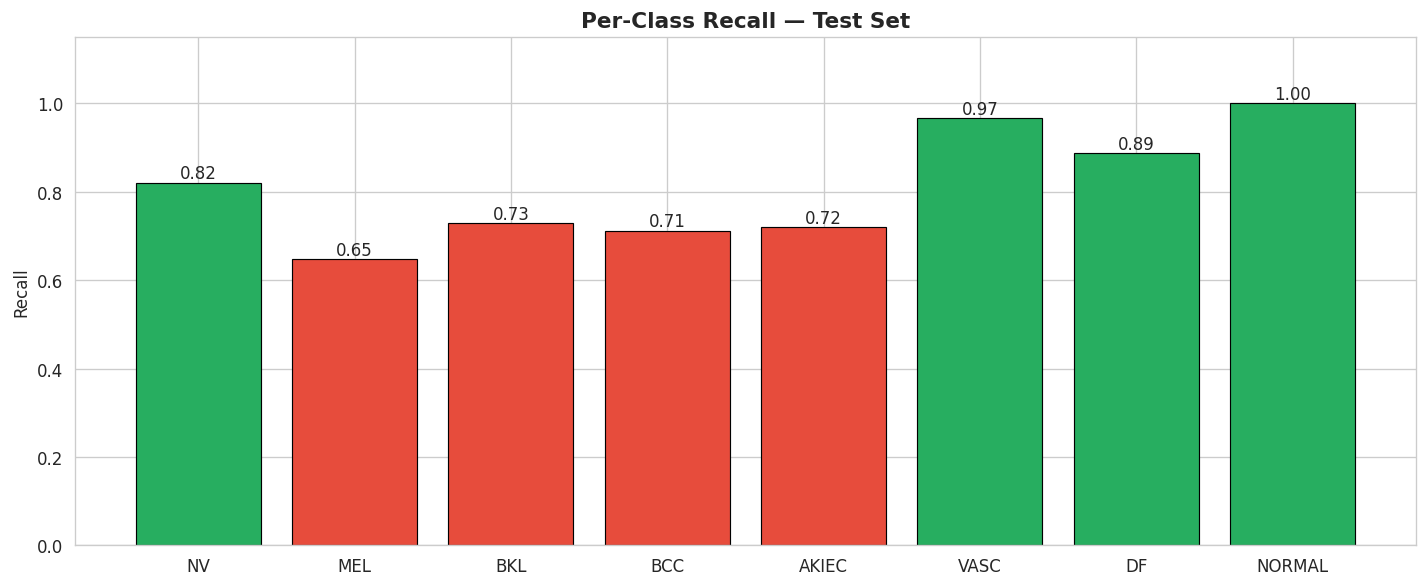

In [24]:
# Per-class recall bar chart
pca    = cm.diagonal()
colors = ['#27ae60' if v >= 0.80 else '#e74c3c' for v in pca]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(ALL_CLASSES, pca, color=colors, edgecolor='black', lw=0.7)
for b, v in zip(bars, pca):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.2f}',
            ha='center', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Recall — Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Recall')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'viz_per_class_recall.png'), bbox_inches='tight')
plt.show()

## Section 8a: Single-Image Inference

Use `predict_image()` to classify **any new image uploaded by a user**.
The function applies the **exact same preprocessing** as training so predictions
are consistent with the trained model distribution.

predict_image() ready.


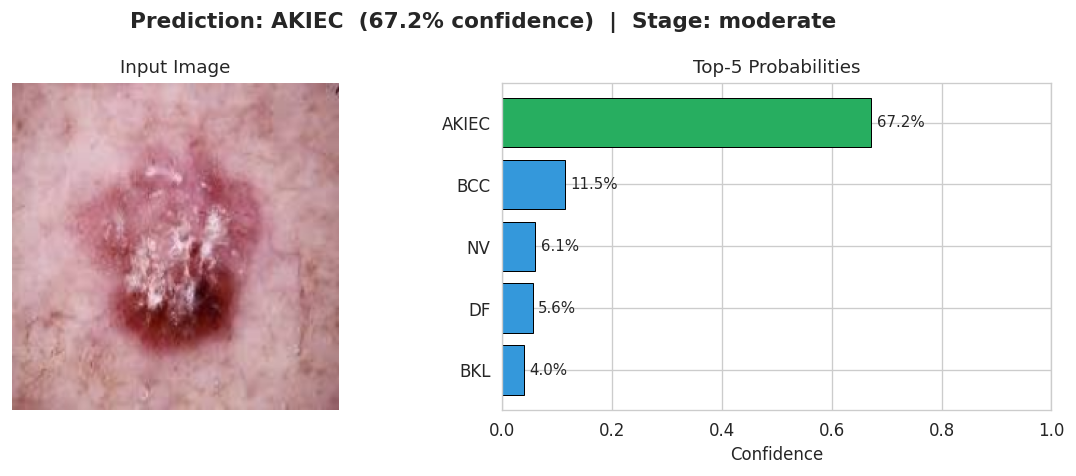


── Prediction ────────────────────────────────────────
  Disease    : AKIEC  (67.19%)
  Stage      : moderate
  AKIEC       67.19% <--
  BCC         11.49%
  NV          6.06%
  DF          5.58%
  BKL         4.01%
──────────────────────────────────────────────────────


In [45]:
def predict_image(image_input, top_k=5, show_plot=True):
    """
    Predict disease class + stage for a new skin image.

    Parameters
    ----------
    image_input : str (file path) or PIL.Image.Image
    top_k       : number of top predictions to display
    show_plot   : if True, renders original + top-k bar chart (no Grad-CAM)

    Returns
    -------
    dict : disease, disease_id, confidence, stage, stage_confidence,
           top_k_predictions
    """
    model.eval()

    # --- Load image -----------------------------------------------------------
    if isinstance(image_input, str):
        pil_img = Image.open(image_input).convert('RGB')
    elif isinstance(image_input, Image.Image):
        pil_img = image_input.convert('RGB')
    else:
        raise TypeError('image_input must be a file path string or PIL Image')

    # --- Preprocess (same pipeline as training) --------------------------------
    img_t = base_transform(pil_img).unsqueeze(0).to(DEVICE)  # (1,3,224,224)

    # --- Forward pass for prediction (no grad needed here) --------------------
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            d_log_no_grad, s_log_no_grad = model(img_t)

    d_prob   = F.softmax(d_log_no_grad, dim=1)[0]    # (8,)
    s_prob   = F.softmax(s_log_no_grad, dim=1)[0]    # (3,)

    pred_id  = int(d_prob.argmax().item())
    pred_lbl = ID_TO_LABEL[pred_id]
    conf     = float(d_prob[pred_id].item())

    # Stage only meaningful for disease classes
    if pred_id != NORMAL_CLASS_ID:
        stage_id   = int(s_prob.argmax().item())
        stage_lbl  = STAGES[stage_id]
        stage_conf = float(s_prob[stage_id].item())
    else:
        stage_id, stage_lbl, stage_conf = -1, 'N/A — healthy skin', 1.0

    # Top-K predictions
    topk_v, topk_i = d_prob.topk(min(top_k, NUM_DISEASE_CLS))
    topk_preds = [
        {'class': ID_TO_LABEL[int(i)], 'confidence': float(v)}
        for i, v in zip(topk_i.tolist(), topk_v.tolist())
    ]

    result = dict(
        disease          = pred_lbl,
        disease_id       = pred_id,
        confidence       = conf,
        stage            = stage_lbl,
        stage_confidence = stage_conf,
        top_k_predictions= topk_preds,
    )

    # --- Grad-CAM and display -------------------------------------------------
    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # Changed to 2 columns
        fig.suptitle(
            f'Prediction: {pred_lbl}  ({conf*100:.1f}% confidence)  |  '
            f'Stage: {stage_lbl}',
            fontsize=13, fontweight='bold'
        )

        # Original
        orig = denorm(img_t.cpu().squeeze()).permute(1,2,0).numpy()
        axes[0].imshow(orig)
        axes[0].set_title('Input Image', fontsize=11)
        axes[0].axis('off')

        # Top-K bar chart (now at index 1)
        tk_cls  = [p['class'] for p in topk_preds]
        tk_conf = [p['confidence'] for p in topk_preds]
        bar_col = ['#27ae60' if c == pred_lbl else '#3498db' for c in tk_cls]
        axes[1].barh(tk_cls[::-1], tk_conf[::-1], color=bar_col[::-1],
                     edgecolor='black', lw=0.6)
        axes[1].set_xlim(0, 1)
        axes[1].set_title(f'Top-{top_k} Probabilities', fontsize=11)
        axes[1].set_xlabel('Confidence')
        for i, (v, c) in enumerate(zip(tk_conf[::-1], tk_conf[::-1])):
            axes[1].text(v + 0.01, i, f'{v*100:.1f}%', va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

    print('\n── Prediction ────────────────────────────────────────')
    print(f'  Disease    : {pred_lbl}  ({conf*100:.2f}%)')
    print(f'  Stage      : {stage_lbl}')
    for p in topk_preds:
        marker = ' <--' if p['class'] == pred_lbl else ''
        print(f'  {p["class"]:10s}  {p["confidence"]*100:.2f}%{marker}')
    print('──────────────────────────────────────────────────────')
    return result


print('predict_image() ready.')
result = predict_image("/content/drive/MyDrive/testimages/akiec1.jpeg")

In [46]:
# Smoke test — one prediction per class (no plot, fast check)
print('Smoke test — one image per class:\n')
smoke = {}
for _, row in test_ds.df.iterrows():
    if row['label'] not in smoke:
        smoke[row['label']] = row['image_path']
    if len(smoke) == NUM_DISEASE_CLS: break

correct = 0
for true_cls, path in smoke.items():
    r = predict_image(path, show_plot=False)
    ok = r['disease'] == true_cls
    correct += int(ok)
    icon = 'OK' if ok else 'WRONG'
    print(f'  [{icon}] True: {true_cls:8s}  Pred: {r["disease"]:8s}  '
          f'Conf: {r["confidence"]*100:.1f}%  Stage: {r["stage"]}')

print(f'\nSmoke accuracy: {correct}/{len(smoke)}')

Smoke test — one image per class:


── Prediction ────────────────────────────────────────
  Disease    : BCC  (87.56%)
  Stage      : severe
  BCC         87.56% <--
  AKIEC       5.67%
  NORMAL      1.56%
  BKL         1.49%
  VASC        1.24%
──────────────────────────────────────────────────────
  [OK] True: BCC       Pred: BCC       Conf: 87.6%  Stage: severe

── Prediction ────────────────────────────────────────
  Disease    : VASC  (41.33%)
  Stage      : severe
  VASC        41.33% <--
  BCC         40.34%
  AKIEC       6.64%
  DF          5.89%
  MEL         3.29%
──────────────────────────────────────────────────────
  [OK] True: VASC      Pred: VASC      Conf: 41.3%  Stage: severe

── Prediction ────────────────────────────────────────
  Disease    : DF  (87.35%)
  Stage      : mild
  DF          87.35% <--
  AKIEC       6.25%
  BCC         4.71%
  VASC        0.60%
  MEL         0.34%
──────────────────────────────────────────────────────
  [OK] True: DF        Pred: DF  

## Section 8b: Test Image Prediction Grid

Display **10 random test images** with their true labels, predicted labels, confidence, and a ✓/✗ indicator.
Images are shown alongside Grad-CAM overlays for easy visual audit.

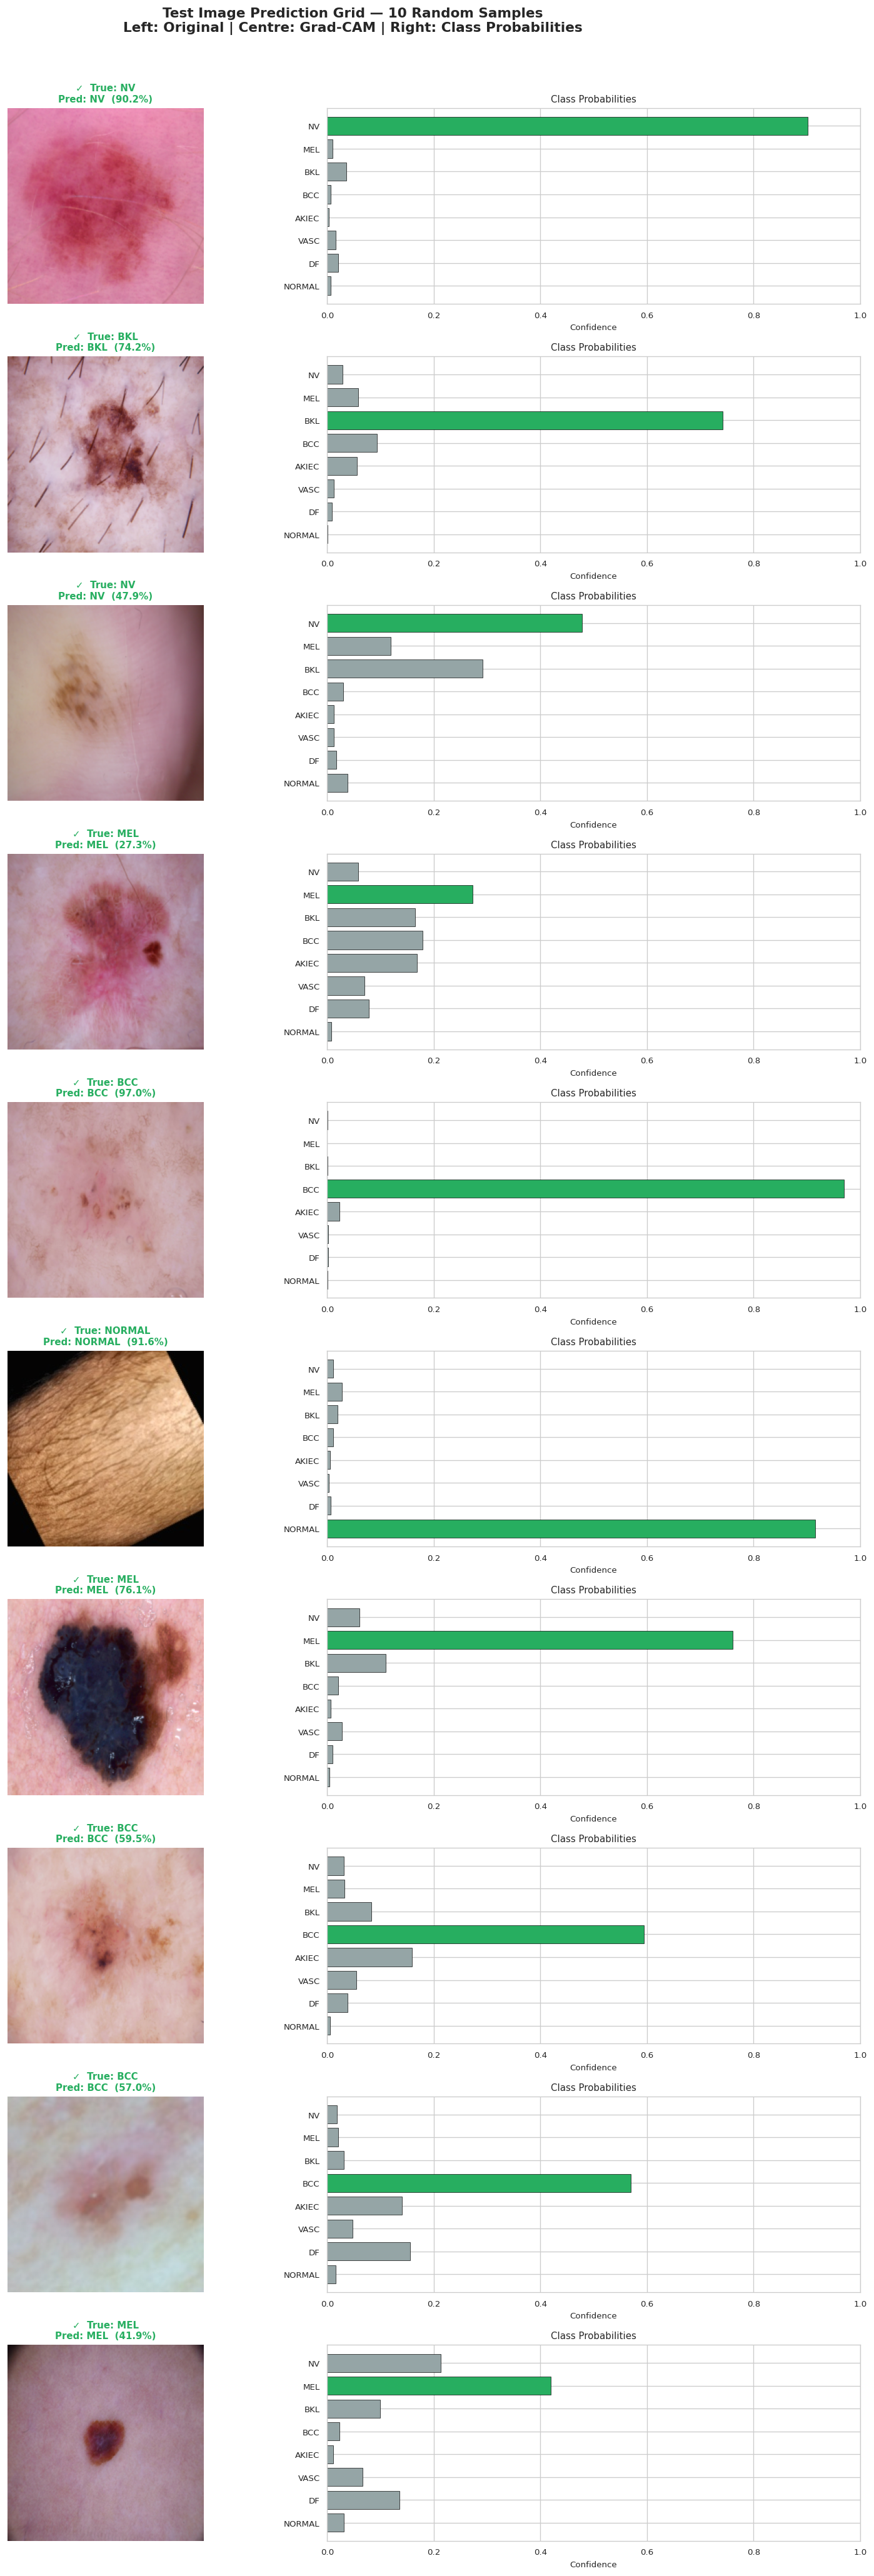

Saved: /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Logs_V3/viz_test_prediction_grid.png


In [47]:
# ── Display 10 test images with predictions ──────────────────────────────────
N_DISPLAY = 10
random.seed(SEED)
display_idxs = random.sample(range(len(test_ds)), N_DISPLAY)

fig, axes = plt.subplots(N_DISPLAY, 2, figsize=(14, N_DISPLAY * 3.5))
fig.suptitle(
    'Test Image Prediction Grid — 10 Random Samples\n'
    'Left: Original | Centre: Grad-CAM | Right: Class Probabilities',
    fontsize=13, fontweight='bold'
)

for row, idx in enumerate(display_idxs):
    img_t, true_id, _ = test_ds[idx]
    true_lbl = ID_TO_LABEL[true_id]

    # ── Forward pass (no grad for speed)
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            d_log, s_log = model(img_t.unsqueeze(0).to(DEVICE))
    d_prob   = F.softmax(d_log, dim=1)[0].cpu()
    s_prob   = F.softmax(s_log, dim=1)[0].cpu()
    pred_id  = int(d_prob.argmax())
    pred_lbl = ID_TO_LABEL[pred_id]
    conf     = float(d_prob[pred_id])
    is_correct = (pred_id == true_id)
    stage_lbl = STAGES[int(s_prob.argmax())] if pred_id != NORMAL_CLASS_ID else 'N/A'

    # ── Column 0: Original image
    orig = denorm(img_t).permute(1,2,0).numpy()
    axes[row, 0].imshow(orig)
    tick = '✓' if is_correct else '✗'
    title_col = '#27ae60' if is_correct else '#e74c3c'
    axes[row, 0].set_title(
        f'{tick}  True: {true_lbl}\nPred: {pred_lbl}  ({conf*100:.1f}%)',
        fontsize=9, color=title_col, fontweight='bold'
    )
    axes[row, 0].axis('off')

    # ── Column 1: Probability bar chart
    bar_colors = [
        '#27ae60' if i == true_id else ('#e74c3c' if i == pred_id else '#95a5a6')
        for i in range(NUM_DISEASE_CLS)
    ]
    axes[row, 1].barh(ALL_CLASSES[::-1],
                      [float(d_prob[i]) for i in range(NUM_DISEASE_CLS)][::-1],
                      color=bar_colors[::-1], edgecolor='black', lw=0.4)
    axes[row, 1].set_xlim(0, 1)
    axes[row, 1].set_xlabel('Confidence', fontsize=8)
    axes[row, 1].tick_params(labelsize=8)
    axes[row, 1].set_title('Class Probabilities', fontsize=9)
    # Green = true class, Red = predicted (if wrong)

plt.tight_layout(rect=[0, 0, 1, 0.97])
grid_path = os.path.join(LOG_DIR, 'viz_test_prediction_grid.png')
plt.savefig(grid_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {grid_path}')

## Section 8c: Upload & Predict

Please upload a skin image (JPG / PNG / WEBP) ...


Saving akiec1.jpeg to akiec1 (1).jpeg

Processing: akiec1 (1).jpeg  (4.0 KB)


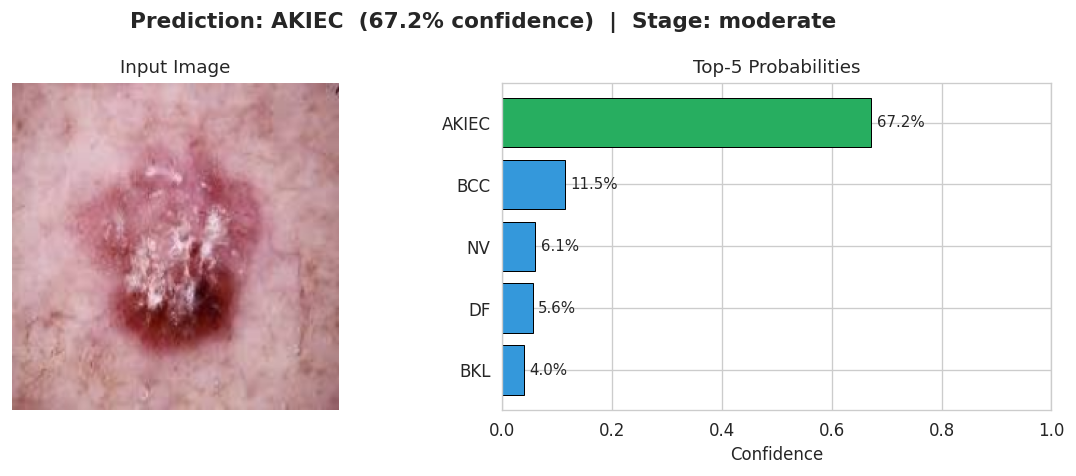


── Prediction ────────────────────────────────────────
  Disease    : AKIEC  (67.19%)
  Stage      : moderate
  AKIEC       67.19% <--
  BCC         11.49%
  NV          6.06%
  DF          5.58%
  BKL         4.01%
──────────────────────────────────────────────────────

────────────────────────────────────────────────────────
  File       : akiec1 (1).jpeg
  Size       : 200×150 px
  Disease    : AKIEC  (67.19% confidence)
  Stage      : moderate
  Top-5:
    AKIEC        67.19%  ◄ predicted
    BCC          11.49%
    NV            6.06%
    DF            5.58%
    BKL           4.01%
────────────────────────────────────────────────────────


In [52]:
# ── Upload disease image and run prediction ───────────────────────────
from google.colab import files as colab_files

print('Please upload a skin image (JPG / PNG / WEBP) ...')
uploaded = colab_files.upload()   # Opens Colab file picker

if not uploaded:
    print('No file uploaded.')
else:
    for fname, data in uploaded.items():
        print(f'\nProcessing: {fname}  ({len(data)/1024:.1f} KB)')

        # Save to a temp path and load as PIL
        tmp_path = f'/content/{fname}'
        with open(tmp_path, 'wb') as fh:
            fh.write(data)

        pil_img = Image.open(tmp_path).convert('RGB')

        # ── Full predict_image pipeline
        result = predict_image(pil_img, top_k=5, show_plot=True)

        # ── Clean text summary
        print('\n' + '─'*56)
        print(f'  File       : {fname}')
        print(f'  Size       : {pil_img.size[0]}×{pil_img.size[1]} px')
        print(f'  Disease    : {result["disease"]}  '
              f'({result["confidence"]*100:.2f}% confidence)')
        print(f'  Stage      : {result["stage"]}')
        print(f'  Top-5:')
        for p in result['top_k_predictions']:
            marker = '  ◄ predicted' if p['class'] == result['disease'] else ''
            print(f'    {p["class"]:10s}  {p["confidence"]*100:6.2f}%{marker}')
        print('─'*56)

Please upload a skin image (JPG / PNG / WEBP) ...


Saving normal2.webp to normal2.webp

Processing: normal2.webp  (323.2 KB)


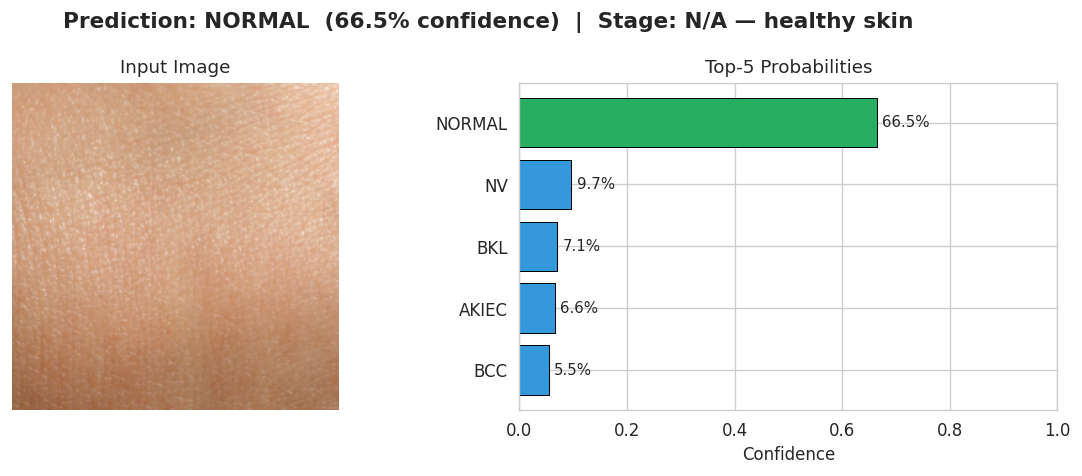


── Prediction ────────────────────────────────────────
  Disease    : NORMAL  (66.46%)
  Stage      : N/A — healthy skin
  NORMAL      66.46% <--
  NV          9.67%
  BKL         7.06%
  AKIEC       6.56%
  BCC         5.46%
──────────────────────────────────────────────────────

────────────────────────────────────────────────────────
  File       : normal2.webp
  Size       : 1241×956 px
  Disease    : NORMAL  (66.46% confidence)
  Stage      : N/A — healthy skin
  Top-5:
    NORMAL       66.46%  ◄ predicted
    NV            9.67%
    BKL           7.06%
    AKIEC         6.56%
    BCC           5.46%
────────────────────────────────────────────────────────


In [50]:
# ── Upload healthy skin image and run prediction ───────────────────────────
from google.colab import files as colab_files

print('Please upload a skin image (JPG / PNG / WEBP) ...')
uploaded = colab_files.upload()   # Opens Colab file picker

if not uploaded:
    print('No file uploaded.')
else:
    for fname, data in uploaded.items():
        print(f'\nProcessing: {fname}  ({len(data)/1024:.1f} KB)')

        # Save to a temp path and load as PIL
        tmp_path = f'/content/{fname}'
        with open(tmp_path, 'wb') as fh:
            fh.write(data)

        pil_img = Image.open(tmp_path).convert('RGB')

        # ── Full predict_image pipeline
        result = predict_image(pil_img, top_k=5, show_plot=True)

        # ── Clean text summary
        print('\n' + '─'*56)
        print(f'  File       : {fname}')
        print(f'  Size       : {pil_img.size[0]}×{pil_img.size[1]} px')
        print(f'  Disease    : {result["disease"]}  '
              f'({result["confidence"]*100:.2f}% confidence)')
        print(f'  Stage      : {result["stage"]}')
        print(f'  Top-5:')
        for p in result['top_k_predictions']:
            marker = '  ◄ predicted' if p['class'] == result['disease'] else ''
            print(f'    {p["class"]:10s}  {p["confidence"]*100:6.2f}%{marker}')
        print('─'*56)

## Section 9: Model Export (ONNX + TFLite)

In [51]:
!pip install -q onnxscript

In [55]:
model.eval()
dummy     = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
onnx_path = os.path.join(EXPORT_DIR, 'skinfusionnet.onnx')

torch.onnx.export(
    model, dummy, onnx_path,
    export_params=True, opset_version=18, do_constant_folding=True,
    input_names=['input_image'],
    output_names=['disease_logits', 'stage_logits'],
    dynamic_axes={
        'input_image'    : {0: 'batch_size'},
        'disease_logits' : {0: 'batch_size'},
        'stage_logits'   : {0: 'batch_size'},
    },
)
onnx.checker.check_model(onnx.load(onnx_path))
print(f'ONNX exported : {onnx_path}  ({os.path.getsize(onnx_path)/1e6:.1f} MB)')

# ONNX runtime spot-check (10 random test images)
sess = ort.InferenceSession(onnx_path,
        providers=['CUDAExecutionProvider','CPUExecutionProvider'])
n_ok = 0
for idx in random.sample(range(len(test_ds)), 10):
    img_t, lbl, _ = test_ds[idx]
    out   = sess.run(None, {'input_image': img_t.unsqueeze(0).numpy()})
    n_ok += int(np.argmax(out[0]) == lbl)
print(f'ONNX runtime spot-check: {n_ok}/10 correct')

W0502 16:15:04.674000 3432 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0502 16:15:04.677000 3432 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0502 16:15:04.679000 3432 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0502 16:15:04.681000 3432 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `SkinFusionNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SkinFusionNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX exported : /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Export_v3/skinfusionnet.onnx  (1.2 MB)
ONNX runtime spot-check: 9/10 correct


In [56]:
# ── TFLite export via onnx2tf ────────────────────────────────────────────────
# onnx2tf is the most reliable ONNX→TFLite path in Colab.
# It converts directly: ONNX → TF SavedModel + TFLite in one command.

!pip install -q onnx2tf 'sng4onnx>=1.0.1' 'onnx_graphsurgeon>=0.3.26' 'simple_onnx_processing_tools>=1.0.0'

import subprocess, sys, shutil, tensorflow as tf

tflite_path = os.path.join(EXPORT_DIR, 'skinfusionnet_fp16.tflite')
tf_saved    = os.path.join(EXPORT_DIR, 'sfn_onnx2tf_saved')

# Move model to CPU for export
model_cpu = model.to('cpu').eval()

print('Converting ONNX → TFLite via onnx2tf ...')
r = subprocess.run([
    sys.executable, '-m', 'onnx2tf',
    '-i', onnx_path,
    '-o', tf_saved,
    '--non_verbose',
], capture_output=True, text=True)

if r.returncode != 0:
    print('onnx2tf stderr:', r.stderr[-600:])
    raise RuntimeError('onnx2tf conversion failed — see stderr above.')

# onnx2tf writes a .tflite alongside the SavedModel — copy it to EXPORT_DIR
tflite_candidates = [f for f in os.listdir(tf_saved) if f.endswith('.tflite')]
if tflite_candidates:
    shutil.copy(os.path.join(tf_saved, tflite_candidates[0]), tflite_path)
    print(f'TFLite copied from onnx2tf output: {tflite_candidates[0]}')
else:
    # SavedModel present but no TFLite yet — convert manually with FP16 optimisation
    print('No .tflite in onnx2tf output — converting SavedModel → TFLite FP16 ...')
    conv = tf.lite.TFLiteConverter.from_saved_model(tf_saved)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.target_spec.supported_types = [tf.float16]
    with open(tflite_path, 'wb') as fh:
        fh.write(conv.convert())

print(f'\nTFLite file : {tflite_path}')
print(f'Size        : {os.path.getsize(tflite_path)/1e6:.1f} MB')

# ── Interpreter smoke-test ────────────────────────────────────────────────────
interp = tf.lite.Interpreter(model_path=tflite_path)
interp.allocate_tensors()
inp_det = interp.get_input_details()
out_det = interp.get_output_details()
print(f'Input  shape : {inp_det[0]["shape"].tolist()}')   # expect [1, 224, 224, 3]
print(f'Output shapes: {[o["shape"].tolist() for o in out_det]}')  # [[1,8],[1,3]]
print('TFLite interpreter smoke-test PASSED.')

# Restore model to original device
model = model_cpu.to(DEVICE)
print(f'\nModel restored to {DEVICE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB

In [57]:
# Save model metadata
meta = {
    'model'              : 'SkinFusionNet',
    'backbone'           : BACKBONE_NAME,
    'img_size'           : IMG_SIZE,
    'num_disease_classes': NUM_DISEASE_CLS,
    'num_stage_classes'  : NUM_STAGE_CLS,
    'classes'            : ALL_CLASSES,
    'stages'             : STAGES,
    'label_to_id'        : LABEL_TO_ID,
    'id_to_label'        : {str(v): k for k,v in LABEL_TO_ID.items()},
    'stage_to_id'        : STAGE_TO_ID,
    'id_to_stage'        : {str(v): k for k,v in STAGE_TO_ID.items()},
    'normalisation'      : {'mean': MEAN, 'std': STD},
    'normal_class_id'    : NORMAL_CLASS_ID,
    'test_accuracy'      : round(test_m['acc'], 4),
    'test_balanced_acc'  : round(test_m['bal_acc'], 4),
    'note': (
        'NORMAL images: stage_id=-1, stage head output ignored. '
        'Grad-CAM alpha=0.20 for NORMAL predictions (diffuse, non-spot heatmap). '
        'No augmentation applied in this notebook — DermAugment already done.'
    ),
}
meta_path = os.path.join(EXPORT_DIR, 'model_metadata.json')
with open(meta_path, 'w') as f: json.dump(meta, f, indent=2)
print(f'Metadata saved: {meta_path}')
print('\nExport directory:')
for fn in sorted(os.listdir(EXPORT_DIR)):
    print(f'  {fn:50s}  {os.path.getsize(os.path.join(EXPORT_DIR,fn))/1e6:.2f} MB')

Metadata saved: /content/drive/MyDrive/DermAugFramework/SkinFusionNet_Export_v3/model_metadata.json

Export directory:
  model_metadata.json                                 0.00 MB
  sfn_onnx2tf_saved                                   0.00 MB
  skinfusionnet.onnx                                  78.47 MB
  skinfusionnet.onnx.data                             79.40 MB
  skinfusionnet_fp16.tflite                           78.50 MB


## Section 10: Final Summary Dashboard

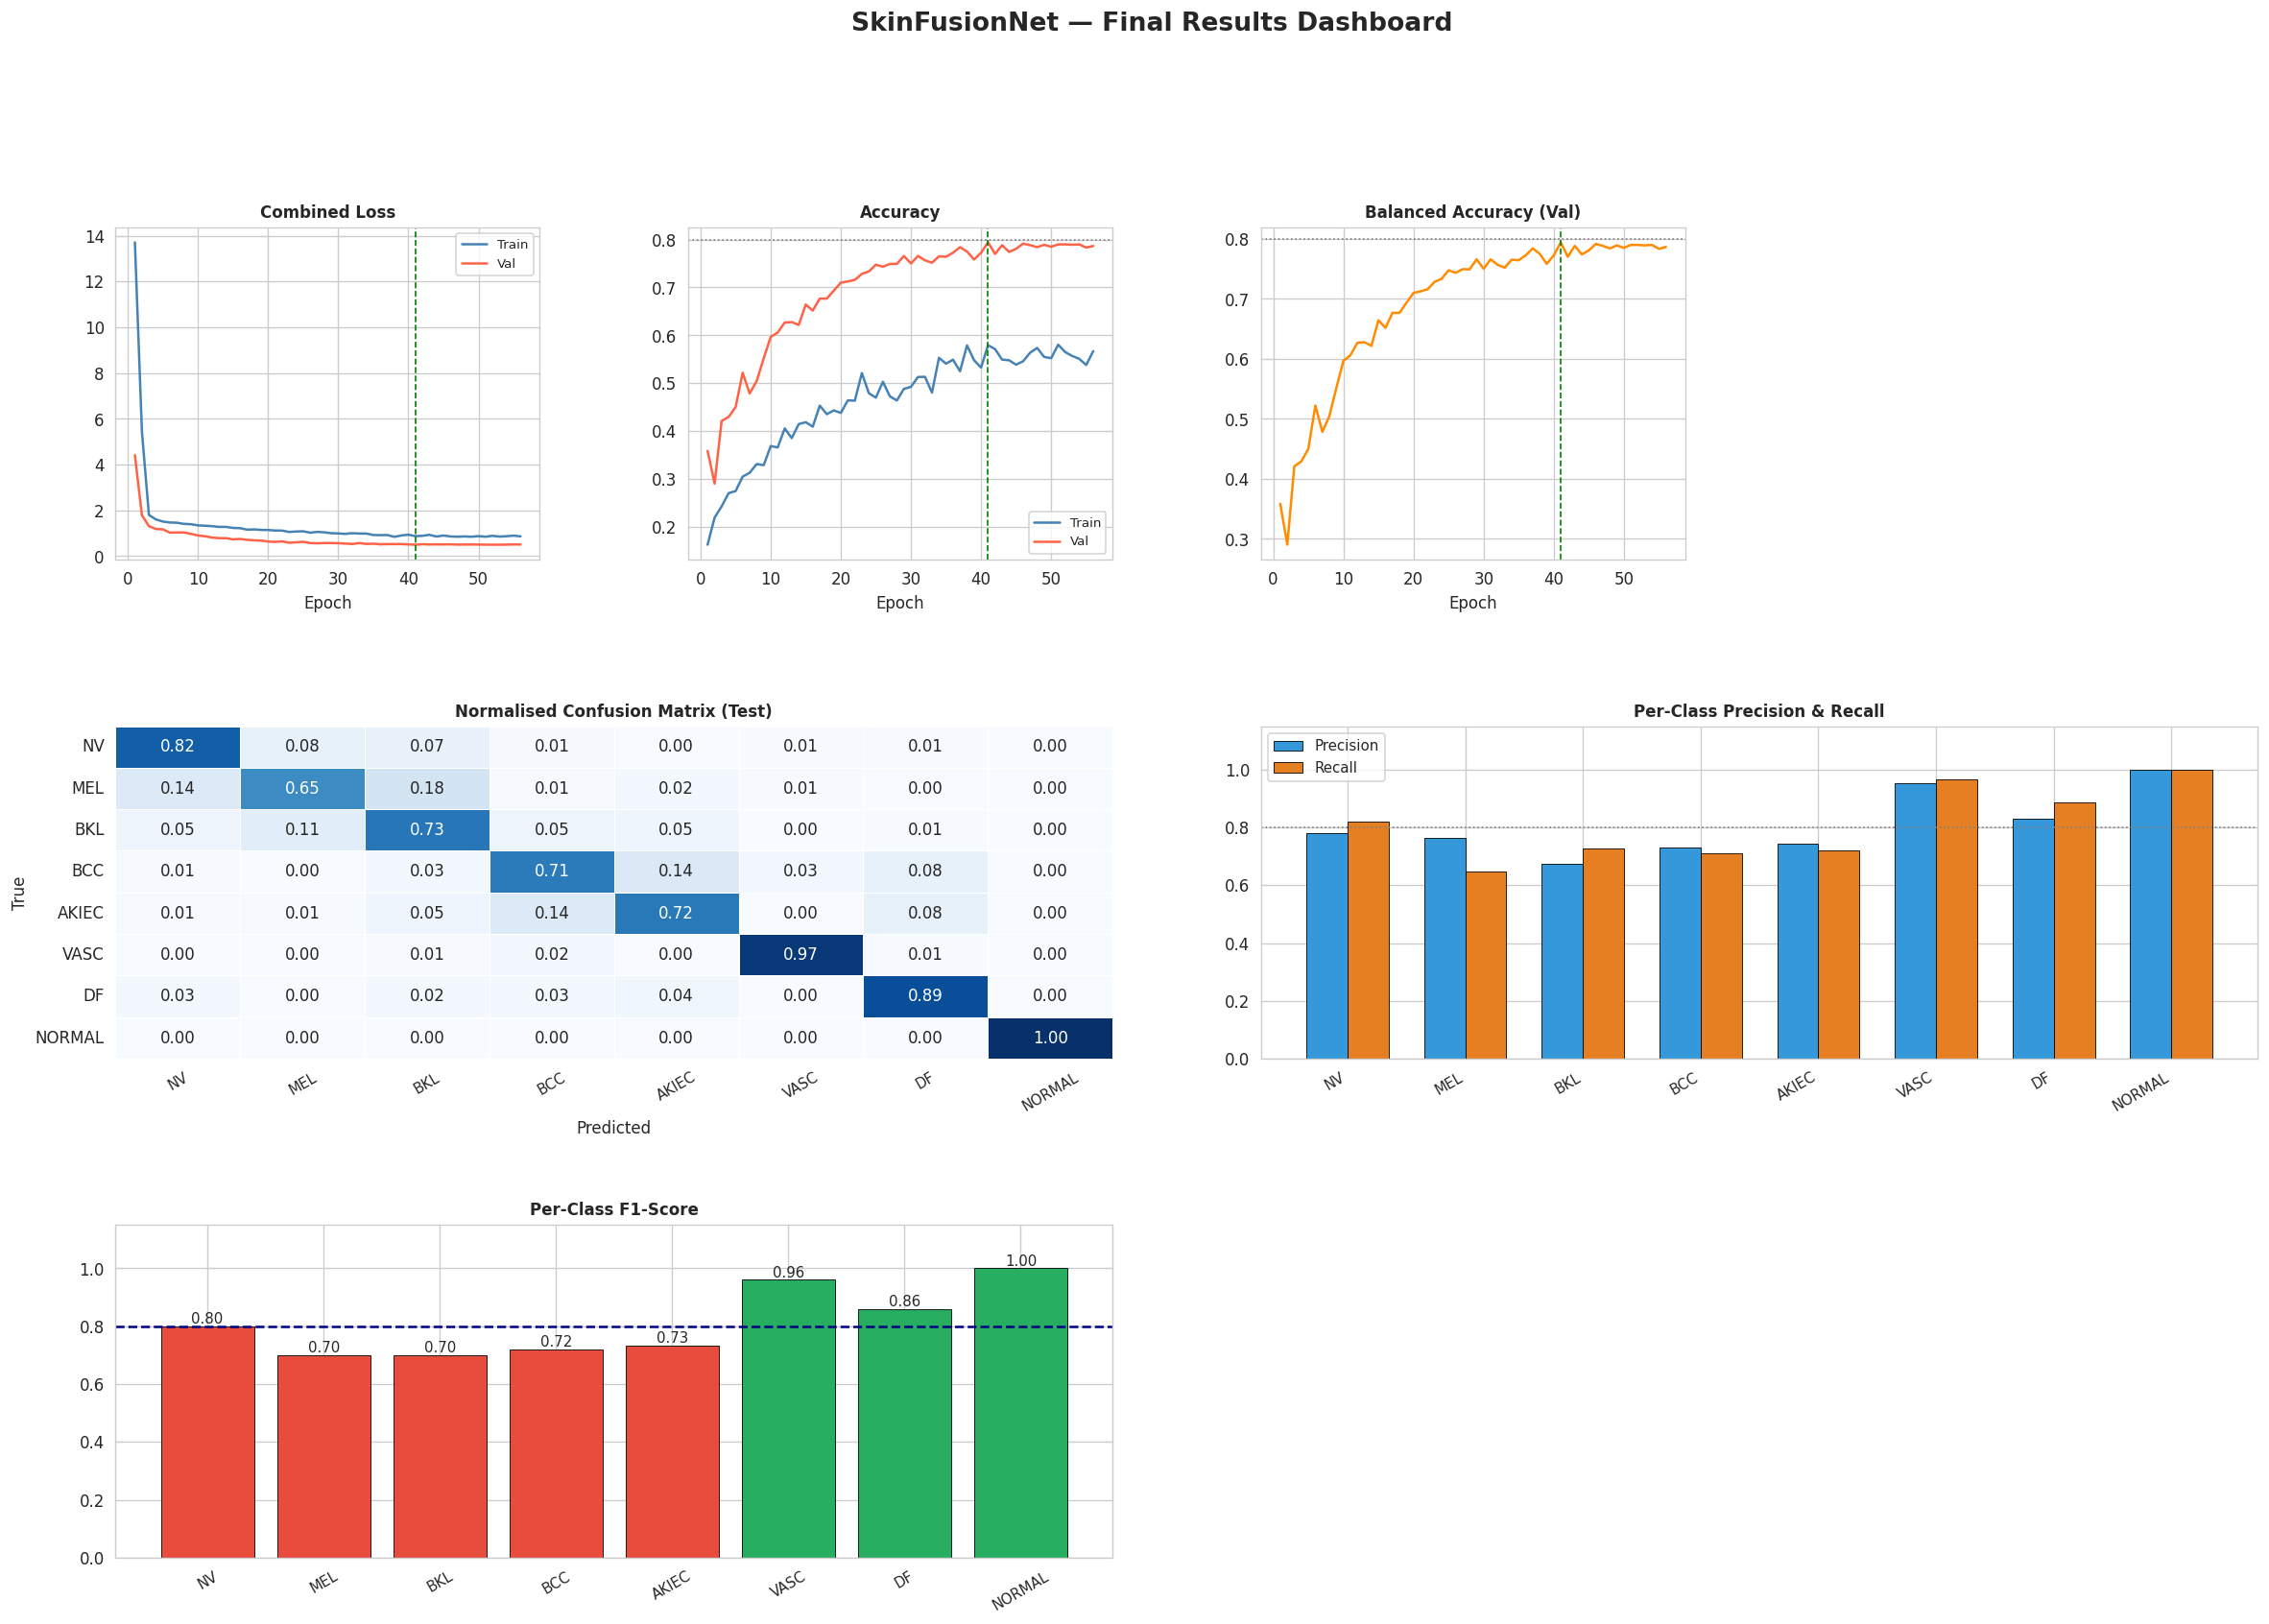

Saved: viz_final_dashboard.png


In [60]:
report = classification_report(
    test_m['labels'], test_m['preds'],
    target_names=ALL_CLASSES, output_dict=True
)

fig = plt.figure(figsize=(24, 15))
fig.suptitle('SkinFusionNet — Final Results Dashboard',
             fontsize=16, fontweight='bold', y=1.005)
gs = fig.add_gridspec(3, 4, hspace=0.50, wspace=0.35)
ep_x = range(1, len(history['tr_loss'])+1)

# Loss
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(ep_x, history['tr_loss'], label='Train', color='steelblue')
ax1.plot(ep_x, history['vl_loss'], label='Val',   color='tomato')
ax1.axvline(best_epoch, color='green', ls='--', lw=1)
ax1.set_title('Combined Loss', fontsize=10, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.legend(fontsize=8)

# Accuracy
ax2 = fig.add_subplot(gs[0,1])
ax2.plot(ep_x, history['tr_acc'], label='Train', color='steelblue')
ax2.plot(ep_x, history['vl_acc'], label='Val',   color='tomato')
ax2.axhline(0.80, color='gray', ls=':', lw=1)
ax2.axvline(best_epoch, color='green', ls='--', lw=1)
ax2.set_title('Accuracy', fontsize=10, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.legend(fontsize=8)

# Balanced accuracy
ax3 = fig.add_subplot(gs[0,2])
ax3.plot(ep_x, history['vl_bal_acc'], color='darkorange')
ax3.axhline(0.80, color='gray', ls=':', lw=1)
ax3.axvline(best_epoch, color='green', ls='--', lw=1)
ax3.set_title('Balanced Accuracy (Val)', fontsize=10, fontweight='bold')
ax3.set_xlabel('Epoch')


# Confusion matrix
ax4 = fig.add_subplot(gs[1,:2])
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=ALL_CLASSES, yticklabels=ALL_CLASSES,
            ax=ax4, linewidths=0.4, cbar=False)
ax4.set_title('Normalised Confusion Matrix (Test)', fontsize=10, fontweight='bold')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')
ax4.tick_params(axis='x', rotation=30, labelsize=9)

# Precision & Recall
ax5 = fig.add_subplot(gs[1,2:])
xp  = np.arange(NUM_DISEASE_CLS); w = 0.35
ax5.bar(xp-w/2, [report[c]['precision'] for c in ALL_CLASSES], w,
        label='Precision', color='#3498db', edgecolor='black', lw=0.5)
ax5.bar(xp+w/2, [report[c]['recall'] for c in ALL_CLASSES], w,
        label='Recall',    color='#e67e22', edgecolor='black', lw=0.5)
ax5.set_xticks(xp); ax5.set_xticklabels(ALL_CLASSES, rotation=30, ha='right', fontsize=9)
ax5.axhline(0.80, color='gray', ls=':', lw=1); ax5.set_ylim(0, 1.15)
ax5.set_title('Per-Class Precision & Recall', fontsize=10, fontweight='bold')
ax5.legend(fontsize=9)

# F1 scores
ax6 = fig.add_subplot(gs[2,:2])
f1s = [report[c]['f1-score'] for c in ALL_CLASSES]
bc  = ['#27ae60' if v >= 0.80 else '#e74c3c' for v in f1s]
bars7 = ax6.bar(ALL_CLASSES, f1s, color=bc, edgecolor='black', lw=0.5)
for b, v in zip(bars7, f1s):
    ax6.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
             f'{v:.2f}', ha='center', fontsize=9)
ax6.axhline(0.80, color='navy', ls='--', lw=1.5)
ax6.set_ylim(0, 1.15)
ax6.set_title('Per-Class F1-Score', fontsize=10, fontweight='bold')
ax6.tick_params(axis='x', rotation=30, labelsize=9)


plt.savefig(os.path.join(LOG_DIR, 'viz_final_dashboard.png'),
            bbox_inches='tight', dpi=130)
plt.show()
print('Saved: viz_final_dashboard.png')

In [61]:
print('=' * 66)
print('  SKINFUSIONNET — COMPLETE')
print('=' * 66)
print(f'  Backbone          : {BACKBONE_NAME}')
print(f'  Classes           : {NUM_DISEASE_CLS}  {ALL_CLASSES}')
print(f'  Images per class  : ~1000 (from DermAugment, no extra aug here)')
print(f'  Best epoch        : {best_epoch}')
print(f'  Test accuracy     : {test_m["acc"]*100:.2f}%')
print(f'  Test balanced acc : {test_m["bal_acc"]*100:.2f}%')

print('=' * 66)

  SKINFUSIONNET — COMPLETE
  Backbone          : efficientnet_b4
  Classes           : 8  ['NV', 'MEL', 'BKL', 'BCC', 'AKIEC', 'VASC', 'DF', 'NORMAL']
  Images per class  : ~1000 (from DermAugment, no extra aug here)
  Best epoch        : 41
  Test accuracy     : 81.00%
  Test balanced acc : 81.00%
